# Sequence Windowing — SDC-2023 & Warwick SE-NAV

This notebook turns two per-measurement tables into **windowed satellite-track
sequences**, ready for the attention-aided bidirectional RNN in
`02_sdc_attention_brnn.ipynb` and `03_attention_transfer.ipynb`.

The design follows Liu et al., *"Attention-aided partial bidirectional RNN-based
nonlinear equalizer in coherent optical systems"*, Opt. Express **30**(18), 2022.
There, an optical symbol is equalised from a window of *k* preceding + *k*
succeeding symbols, and an attention block over the BRNN hidden states reveals how
many neighbouring symbols actually carry information. The claim we are porting is
structural, not optical:

> **A measurement is easier to classify when you can see its neighbours in time,
> and attention can tell you how many neighbours are worth keeping.**

So instead of classifying each `(epoch, satellite)` measurement independently —
which is what the Random Forest / HistGBM pipeline in
`03_2023_classification.ipynb` does — each measurement is classified from a
window of `2k+1` consecutive epochs **of that same satellite track**, labelled by
the `MultipathIndicator` of the **centre** epoch. We start at `k = 20`, matching
the paper's 41-symbol window.

**Inputs**
- `data/02_interim/sdc2023_epochs.csv` — built by `2023_notebooks/01_2023_data_parser.ipynb`
- `data/01_raw/Warwick/*.m` — SE-NAV ray-tracing simulation, parsed exactly as in
  `warwick_multipath/warwick_senav_deepdive.ipynb`

**Outputs**
- `data/03_processed/seq_sdc2023.npz`
- `data/03_processed/seq_warwick.npz`

### Why this notebook caches rows rather than windows
A window is a *view* of `2k+1` consecutive rows. Materialising every window
densely would store each row `2k+1` times — about **1.5 GB** for SDC-2023 at
`k = 20`. Instead we cache the per-row feature matrix once, plus the segment
boundaries, and gather windows on the fly at training time. That is not only
~40× smaller, it means **a single cache serves every value of k** in the trimmed-
window sweep of notebook 02 — no re-export per k.

## 0. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())          # so `attn_brnn.py` next to this notebook is importable
from attn_brnn import segment_ids, valid_centers

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '../..'))
SDC_CSV   = os.path.join(BASE_DIR, 'data/02_interim/sdc2023_epochs.csv')
WARWICK   = os.path.join(BASE_DIR, 'data/01_raw/Warwick')
OUT_DIR   = os.path.join(BASE_DIR, 'data/03_processed')
os.makedirs(OUT_DIR, exist_ok=True)

K_MAX       = 20        # half-window; the cache supports every k <= K_MAX
MAX_GAP_S   = 1.5       # a larger sampling gap starts a new segment
SEED        = 42

print('SDC   :', SDC_CSV, '| exists:', os.path.exists(SDC_CSV))
print('Warwick:', WARWICK, '| exists:', os.path.isdir(WARWICK))

SDC   : C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/02_interim/sdc2023_epochs.csv | exists: True
Warwick: C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/01_raw/Warwick | exists: True


## 1. SDC-2023 — load the interim measurement table

Note two departures from the notebook brief, both forced by what is actually on disk:

1. **There is no `utcTimeMillis` column.** `01_2023_data_parser.ipynb` drops it at
   export (`final_df.drop(columns=['TimeNanos','FullBiasNanos','utcTimeMillis'])`).
   It does keep **`GpsTimeNanos`** — GPS time of week in nanoseconds — which orders
   epochs just as well. No session spans a GPS week rollover (all are 0.3–0.6 h
   long), so this is monotone within every track.
2. **`BasebandCn0DbHz`, `SnrInDb` and `AgcDb` are 100% NaN** in this dataset, so
   they cannot be used, matching the `Dropped all-NaN` result in
   `04_2023_routen_deepdive.ipynb`.

In [2]:
USECOLS = [
    'session', 'device', 'ConstellationType', 'Svid', 'CarrierFrequencyHz', 'GpsTimeNanos',
    'Cn0DbHz', 'SvElevationDegrees', 'SvAzimuthDegrees', 'prResidual',
    'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond',
    'ReceivedSvTimeUncertaintyNanos', 'AccumulatedDeltaRangeUncertaintyMeters',
    'RawPseudorangeUncertaintyMeters', 'MultipathIndicator',
]
sdc = pd.read_csv(SDC_CSV, usecols=USECOLS)
print(f'Loaded {len(sdc):,} measurements  |  {sdc.session.nunique()} sessions  |  '
      f'{sdc.device.nunique()} devices')
print(f'Multipath rate: {100 * sdc.MultipathIndicator.mean():.2f}%')
print('\nNaN % per column:')
print((sdc.isna().mean() * 100).round(2).to_string())

Loaded 761,597 measurements  |  17 sessions  |  3 devices
Multipath rate: 7.02%

NaN % per column:
Svid                                         0.00
ReceivedSvTimeUncertaintyNanos               0.00
Cn0DbHz                                      0.00
PseudorangeRateMetersPerSecond               0.00
PseudorangeRateUncertaintyMetersPerSecond    0.00
AccumulatedDeltaRangeUncertaintyMeters       0.00
CarrierFrequencyHz                           4.32
ConstellationType                            0.00
MultipathIndicator                           0.00
SvElevationDegrees                           5.22
SvAzimuthDegrees                             5.22
RawPseudorangeUncertaintyMeters              5.22
session                                      0.00
device                                       0.00
GpsTimeNanos                                 0.00
prResidual                                   5.22


### 1a. Defining a satellite track

The obvious key `(session, device, Svid)` is **wrong for this dataset** — it leaves
334,455 duplicate rows, because:

- the pixel7pro tracks **two frequency bands at once** (L1 at 1575 MHz and L5 at
  1176 MHz) for the same satellite in the same epoch; and
- `Svid` is only unique *within* a constellation — GPS 7 and Galileo 7 are
  different satellites.

Feeding a mixed-band, mixed-constellation sequence to a recurrent model would
interleave two independent physical channels into one "track" and manufacture
exactly the kind of spurious temporal structure this study is trying to measure.
The correct key is
`(session, device, ConstellationType, Svid, CarrierFrequencyHz)`.

In [3]:
TRACK_KEY = ['session', 'device', 'ConstellationType', 'Svid', 'CarrierFrequencyHz']

print('Duplicate rows under each candidate track key (per epoch):')
for key in (['session', 'device', 'Svid'], TRACK_KEY):
    d = sdc.duplicated(key + ['GpsTimeNanos']).sum()
    print(f'  {str(key):<95} {d:>8,}')

# CarrierFrequencyHz is NaN for 4.3% of rows; give those their own band so they form
# separate tracks rather than being silently merged into a real band.
sdc['CarrierFrequencyHz'] = sdc['CarrierFrequencyHz'].fillna(-1.0)

Duplicate rows under each candidate track key (per epoch):


  ['session', 'device', 'Svid']                                                                    334,455


  ['session', 'device', 'ConstellationType', 'Svid', 'CarrierFrequencyHz']                               0


### 1b. Drop rows without the core physical features

Elevation, azimuth and `prResidual` are NaN together on the same 5.2% of rows
(they all derive from the satellite-position columns). A recurrent model has no
equivalent of a tree's missing-value split, and imputing them would inject a
constant into the very sequences whose temporal structure we are measuring — so
these rows are dropped before segmentation, which also correctly *breaks* the
track at that point.

In [4]:
CORE = ['Cn0DbHz', 'SvElevationDegrees', 'SvAzimuthDegrees', 'prResidual',
        'PseudorangeRateMetersPerSecond', 'MultipathIndicator']
n0 = len(sdc)
sdc = sdc.dropna(subset=CORE).reset_index(drop=True)
print(f'Dropped {n0 - len(sdc):,} rows ({100*(n0-len(sdc))/n0:.2f}%) missing core features  '
      f'|  kept {len(sdc):,}')
print(f'Multipath rate after drop: {100 * sdc.MultipathIndicator.mean():.2f}%')

Dropped 39,765 rows (5.22%) missing core features  |  kept 721,832
Multipath rate after drop: 6.29%


## 2. Session-level train / validation / test split

The split is by **session (whole drive)**, not by row and not by time-within-drive.
A random row split would put a measurement and its own immediate neighbours on
opposite sides of the split — with 41-epoch windows overlapping by 40 epochs that
is near-total leakage, and any "temporal memory" result would be meaningless. Even
the within-drive temporal 70/30 split used by `04_2023_routen_deepdive.ipynb`
leaves train and test on the *same route*, so a model could score well by
recognising the road rather than the physics.

Holding out entire drives is the strict option: the test sessions are roads,
skies and satellite geometries the model has never seen. **The test sessions are
not touched until final reporting.** Both devices in a shared session go to the
same side, so the same drive can never appear on both.

With only 17 sessions, *which* drives land where matters a lot: the per-session
multipath rate ranges from 3.0% to 12.5%, so an unlucky draw can hand the model a
4%-multipath training set and an 8%-multipath test set, and the resulting score
would say more about the draw than about the model. So rather than taking the
first random split, we sample many whole-session assignments and keep the one
whose splits are simultaneously closest to the target **row fractions** and to the
**global multipath rate**.

This is a property of the *data partition* only — the objective never touches a
model, a prediction or a feature, so it cannot tune the split in any model's
favour. It is the sequence-model equivalent of the `stratify=y` argument used by
`03_2023_classification.ipynb`, which is unavailable here because the unit being
stratified is a whole drive rather than a row.

In [5]:
TARGETS = np.array([0.55, 0.15, 0.30])          # train / val / test row fractions
SPLIT_NAMES = ['train', 'val', 'test']

agg = sdc.groupby('session')['MultipathIndicator'].agg(['size', 'sum'])
sess_names = agg.index.to_numpy()
sess_rows, sess_pos = agg['size'].to_numpy(float), agg['sum'].to_numpy(float)
N, global_rate = sess_rows.sum(), sess_pos.sum() / sess_rows.sum()

rng = np.random.default_rng(SEED)
M = 400_000
A = rng.integers(0, 3, size=(M, len(sess_names)))
frac = np.empty((M, 3)); rate = np.empty((M, 3))
for k in range(3):
    m = (A == k).astype(float)
    r, p = m @ sess_rows, m @ sess_pos
    frac[:, k] = r / N
    rate[:, k] = np.divide(p, r, out=np.full(M, np.nan), where=r > 0)

# tolerances: 5 percentage points of row share, 1 percentage point of class rate
score = np.abs(frac - TARGETS).sum(1) / 0.05 + np.abs(rate - global_rate).sum(1) / 0.01
score[~(frac > 0.05).all(1)] = np.inf
best = A[int(np.argmin(score))]
assign = dict(zip(sess_names, [SPLIT_NAMES[b] for b in best]))
sdc['split'] = sdc.session.map(assign)

print(f'Searched {M:,} whole-session assignments  |  global multipath rate '
      f'{100*global_rate:.2f}%\n')
print(f'{"split":6} {"sessions":>9} {"rows":>10} {"% rows":>8} {"% multipath":>12}')
for name in SPLIT_NAMES:
    m = sdc.split == name
    print(f'{name:6} {sdc[m].session.nunique():>9} {m.sum():>10,} {100*m.mean():>7.1f}% '
          f'{100*sdc.loc[m, "MultipathIndicator"].mean():>11.2f}%')
for name in SPLIT_NAMES:
    print(f'\n{name} sessions:')
    for s in sorted(k for k, v in assign.items() if v == name):
        print('   ', s)

Searched 400,000 whole-session assignments  |  global multipath rate 6.29%

split   sessions       rows   % rows  % multipath
train          9    400,928    55.5%        6.32%
val            3    108,575    15.0%        6.16%


test           5    212,329    29.4%        6.29%

train sessions:
    2023-03-08-21-34-us-ca-mtv-u
    2023-05-09-21-32-us-ca-mtv-pe1
    2023-05-16-19-55-us-ca-mtv-xe1
    2023-05-25-19-10-us-ca-sjc-be2
    2023-05-25-20-11-us-ca-sjc-he2
    2023-09-06-00-01-us-ca-routen
    2023-09-06-18-04-us-ca
    2023-09-07-18-59-us-ca
    2023-09-07-22-47-us-ca-routebc2

val sessions:
    2023-05-19-20-10-us-ca-mtv-ie2
    2023-09-06-18-47-us-ca
    2023-09-07-19-33-us-ca

test sessions:
    2023-05-24-20-26-us-ca-sjc-ge2
    2023-05-26-18-51-us-ca-sjc-ge2
    2023-09-05-20-13-us-ca
    2023-09-05-23-07-us-ca-routen
    2023-09-06-22-49-us-ca-routebb1


## 3. Segmentation — where a window is allowed to live

A window may only span rows that are genuinely consecutive observations of one
satellite. Rows are grouped into **segments**, broken whenever

- the satellite track changes,
- the sampling gap exceeds `MAX_GAP_S = 1.5 s` (98.7% of gaps are exactly 1 s; the
  rest are re-acquisitions after signal loss and must not be bridged), or
- the train/val/test split changes.

Folding the split into the segmentation is what guarantees the split is leak-free
for sequences: a window that would straddle a boundary simply has no valid centre
and is never built. Windows falling off either end of a segment are dropped rather
than zero-padded — padding would feed the attention block invented epochs and bias
the discovered window shape toward the centre.

In [6]:
sdc['track'] = sdc.groupby(TRACK_KEY, dropna=False, sort=False).ngroup()
sdc['t_s'] = sdc['GpsTimeNanos'] / 1e9
sdc = sdc.sort_values(['track', 't_s'], kind='stable').reset_index(drop=True)

grp = sdc.groupby(['track', 'split'], sort=False).ngroup().to_numpy()
sdc['seg'] = segment_ids(grp, sdc['t_s'].to_numpy(), max_gap_s=MAX_GAP_S)

seg_len = sdc.groupby('seg').size()
print(f'{sdc.track.nunique():,} tracks  ->  {len(seg_len):,} contiguous segments')
print('Segment length (epochs):')
print(seg_len.describe().round(1).to_string())
print(f'\nSegments long enough for k={K_MAX} (>= {2*K_MAX+1} epochs): '
      f'{(seg_len >= 2*K_MAX+1).sum():,} covering {seg_len[seg_len >= 2*K_MAX+1].sum():,} rows')

596 tracks  ->  14,200 contiguous segments
Segment length (epochs):
count    14200.0
mean        50.8
std        136.0
min          1.0
25%          2.0
50%          8.0
75%         34.0
max       2130.0

Segments long enough for k=20 (>= 41 epochs): 3,208 covering 629,154 rows


### 3a. How many windows survive, as a function of k

Each extra epoch of context costs `2` usable centres per segment, so the yield
falls slowly with `k` — this is the price of the paper's "drop windows that fall
off the edge" rule, and it is what the trimmed/partial model in notebook 02 buys
back.

 k  T  windows  pct_rows  pct_multipath
 1  3   695931     96.41           5.86
 2  5   676329     93.70           5.62
 3  7   659839     91.41           5.49
 5 11   631980     87.55           5.33
 8 17   597650     82.80           5.18
12 25   559867     77.56           5.04
20 41   500834     69.38           4.84
30 61   444037     61.52           4.67
40 81   398818     55.25           4.54


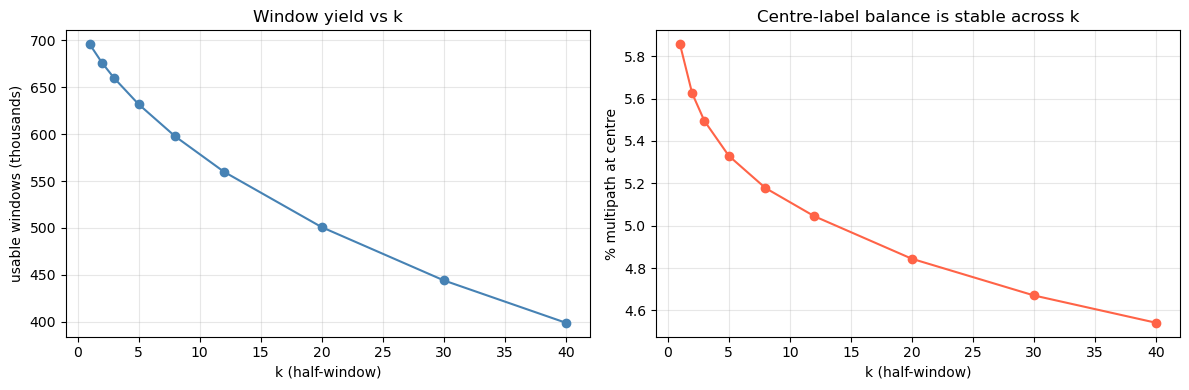

In [7]:
rows = []
for k in [1, 2, 3, 5, 8, 12, 20, 30, 40]:
    c = valid_centers(sdc['seg'].to_numpy(), k)
    if len(c) == 0:
        rows.append(dict(k=k, T=2*k+1, windows=0, pct_rows=0.0, pct_multipath=np.nan)); continue
    yk = sdc['MultipathIndicator'].to_numpy()[c]
    rows.append(dict(k=k, T=2*k+1, windows=len(c),
                     pct_rows=100*len(c)/len(sdc), pct_multipath=100*yk.mean()))
window_yield = pd.DataFrame(rows)
print(window_yield.round(2).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(window_yield.k, window_yield.windows / 1e3, 'o-', color='steelblue')
ax[0].set_xlabel('k (half-window)'); ax[0].set_ylabel('usable windows (thousands)')
ax[0].set_title('Window yield vs k'); ax[0].grid(alpha=0.3)
ax[1].plot(window_yield.k, window_yield.pct_multipath, 'o-', color='tomato')
ax[1].set_xlabel('k (half-window)'); ax[1].set_ylabel('% multipath at centre')
ax[1].set_title('Centre-label balance is stable across k'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Feature schemas

Two channel sets are built over the **same** windows:

| schema | channels | used for |
|---|---|---|
| **rich** | C/N0, elevation, az sin/cos, signed-log `prResidual` + magnitude, pseudorange rate, four log-uncertainties, constellation one-hot, L5 flag | the honest comparison against the RF / HistGBM baselines in `03_2023_classification.ipynb`, which see comparable per-row features |
| **shared** | C/N0, elevation, az sin/cos | the Warwick transfer in notebook 03 — the only features the SE-NAV simulation also provides, matching `engineer()` in `sdc_to_warwick_transfer.ipynb` |

Two transforms differ from the tabular pipeline, and both are there because a
neural network is not a decision tree:

- **Azimuth becomes `sin`/`cos`.** Same as `engineer()`: 359° and 1° must be
  adjacent, not maximally distant.
- **Heavy-tailed columns get a signed log.** `prResidual` runs from −296 km to
  +40 km with a 99.9th percentile of 4.6 km. Trees are invariant to that; a
  standardised network input is not — a handful of kilometre-scale outliers would
  dominate the scale and flatten every real variation to ~0. `sign(x)·log1p(|x|)`
  is monotone, keeps the sign (which distinguishes an early from a late arrival)
  and compresses the tail. The uncertainty columns, which are positive and
  similarly skewed, get plain `log1p`.
- **`AccumulatedDeltaRangeUncertaintyMeters` is split into a flag and a value.**
  32.8% of rows carry exactly `3.402823e38` — float32 max, the Android sentinel
  for "carrier phase unusable", not a measurement. Log-scaling it produces a
  grotesque bimodal channel at {≈0, 88.7}. The sentinel is nonetheless *strongly*
  informative (12.4% multipath on sentinel rows vs 4.4% otherwise), so it is
  encoded honestly: a binary `adr_invalid` flag carries the fact that the phase
  lock failed, and `adrUnc_log` carries the real uncertainty where one exists.

Nothing is standardised here — scalers are fit on the **training rows only**,
inside notebook 02, matching the leak-free convention of the existing notebooks.

In [8]:
def slog(x):
    """Signed log: monotone, sign-preserving, tail-compressing."""
    x = np.asarray(x, dtype=np.float64)
    return np.sign(x) * np.log1p(np.abs(x))

ADR_SENTINEL = 1e30      # anything at/above this is float32-max "unusable", not a value

CONST_NAMES = {1: 'GPS', 3: 'GLONASS', 5: 'BeiDou', 6: 'Galileo', 4: 'QZSS', 2: 'SBAS'}

def sdc_features(d):
    az = np.radians(d['SvAzimuthDegrees'].to_numpy())
    adr = d['AccumulatedDeltaRangeUncertaintyMeters'].fillna(ADR_SENTINEL).to_numpy()
    adr_bad = adr >= ADR_SENTINEL
    f = pd.DataFrame({
        'Cn0DbHz':        d['Cn0DbHz'].to_numpy(),
        'elev_deg':       d['SvElevationDegrees'].to_numpy(),
        'az_sin':         np.sin(az),
        'az_cos':         np.cos(az),
        'prResidual_slog':     slog(d['prResidual']),
        'abs_prResidual_log':  np.log1p(np.abs(d['prResidual'].to_numpy())),
        'prRate':         d['PseudorangeRateMetersPerSecond'].to_numpy(),
        'prRateUnc_log':  np.log1p(d['PseudorangeRateUncertaintyMetersPerSecond'].fillna(0).to_numpy()),
        'svTimeUnc_log':  np.log1p(d['ReceivedSvTimeUncertaintyNanos'].fillna(0).to_numpy()),
        'adr_invalid':    adr_bad.astype(float),
        'adrUnc_log':     np.log1p(np.where(adr_bad, 0.0, adr)),
        'prUnc_log':      np.log1p(d['RawPseudorangeUncertaintyMeters'].fillna(0).to_numpy()),
        'is_L5':          (d['CarrierFrequencyHz'].to_numpy() < 1.3e9).astype(float),
    })
    for code, name in [(1, 'GPS'), (4, 'QZSS'), (5, 'BeiDou'), (6, 'Galileo')]:
        f[f'Const_{name}'] = (d['ConstellationType'].to_numpy() == code).astype(float)
    return f

F_rich_df = sdc_features(sdc)
SHARED_COLS = ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos']

RICH_FEATURES   = list(F_rich_df.columns)
SHARED_FEATURES = SHARED_COLS

print(f'rich schema   ({len(RICH_FEATURES)} channels): {RICH_FEATURES}')
print(f'shared schema ({len(SHARED_FEATURES)} channels): {SHARED_FEATURES}')
assert not F_rich_df.isna().any().any(), 'NaN leaked into the feature matrix'
print('\nFeature summary (unscaled):')
print(F_rich_df.describe().T[['mean', 'std', 'min', 'max']].round(3).to_string())

rich schema   (17 channels): ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos', 'prResidual_slog', 'abs_prResidual_log', 'prRate', 'prRateUnc_log', 'svTimeUnc_log', 'adr_invalid', 'adrUnc_log', 'prUnc_log', 'is_L5', 'Const_GPS', 'Const_QZSS', 'Const_BeiDou', 'Const_Galileo']
shared schema (4 channels): ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos']

Feature summary (unscaled):


                      mean      std      min      max
Cn0DbHz             32.348    6.035   20.000   49.291
elev_deg            38.283   21.530    2.497   88.569
az_sin              -0.054    0.756   -1.000    1.000
az_cos               0.039    0.652   -1.000    1.000
prResidual_slog     -0.029    2.723  -12.598   10.603
abs_prResidual_log   2.557    0.936    0.000   12.598
prRate             -18.170  389.106 -870.722  742.065
prRateUnc_log        0.618    0.924    0.033    5.706
svTimeUnc_log        2.989    0.757    1.946    6.211
adr_invalid          0.297    0.457    0.000    1.000
adrUnc_log           0.006    0.019    0.000    0.101
prUnc_log            1.923    0.669    1.029    5.011
is_L5                0.414    0.493    0.000    1.000
Const_GPS            0.496    0.500    0.000    1.000
Const_QZSS           0.021    0.145    0.000    1.000
Const_BeiDou         0.017    0.129    0.000    1.000
Const_Galileo        0.466    0.499    0.000    1.000


## 5. Warwick SE-NAV — parse and window the simulation

The parser is the `blocks()` regex from `warwick_senav_deepdive.ipynb`, unchanged.
Each of the 11 GPS PRNs forms one track over `epoch`; the label is `Visibility == 1`
(NLOS, direct path blocked).

Warwick gets a **temporal** split rather than a session split for a simple reason:
it is a single drive, so there are no sessions to hold out. First 60% of epochs
train, next 10% validation, last 30% test — the same shape as the temporal split in
the SDC and Warwick deep-dive notebooks. Because the split is folded into
segmentation, no window straddles a boundary.

In [9]:
import re

_BLK = re.compile(r'(\w+)\(([^)]*)\)\s*=\s*\[(.*?)\]\s*;', re.S)

def blocks(fn):
    with open(os.path.join(WARWICK, fn), 'r', errors='ignore') as fh:
        txt = fh.read()
    return _BLK.findall('\n'.join(l for l in txt.splitlines() if not l.startswith('//')))

ep_of = lambda i: int(i.split(',')[-1])

visi = {ep_of(i): [int(x) for x in b.split()] for _, i, b in blocks('Visibility.m')}
con  = {ep_of(i): np.array([[float(x) for x in r.split()] for r in b.split(';') if r.strip()])
        for _, i, b in blocks('Constellation.m')}
chan = {}
for _, i, b in blocks('Channels.m'):
    chan[ep_of(i)] = {int(float(p[2])): (float(p[3]), float(p[4]))
                      for p in (r.split() for r in b.split(';')) if len(p) >= 5}

recs = []
for t, arr in visi.items():
    if t not in con:
        continue
    M, ch = con[t], chan.get(t, {})
    for i, vis in enumerate(arr):
        if vis == 0:
            continue
        prn = int(M[i, 0])
        power, snr = ch.get(prn, (np.nan, np.nan))
        recs.append((t, prn, np.degrees(M[i, 10]), np.degrees(M[i, 11]) % 360,
                     snr, power, 1 if vis == 1 else 0))

war = (pd.DataFrame(recs, columns=['epoch', 'PRN', 'elevation_deg', 'azimuth_deg',
                                   'snr_dbHz', 'power_dbW', 'multipath'])
       .dropna(subset=['snr_dbHz', 'power_dbW', 'elevation_deg'])
       .sort_values(['PRN', 'epoch'], kind='stable').reset_index(drop=True))

print(f'Warwick: {len(war):,} rows  |  {war.epoch.nunique():,} epochs  |  {war.PRN.nunique()} PRNs')
print(f'NLOS rate: {100 * war.multipath.mean():.1f}%')
print('Track lengths (epochs):')
print(war.groupby('PRN').size().describe().round(1).to_string())

Warwick: 24,849 rows  |  2,842 epochs  |  11 PRNs
NLOS rate: 20.0%
Track lengths (epochs):
count      11.0
mean     2259.0
std       768.9
min         2.0
25%      2307.5
50%      2467.0
75%      2563.5
max      2842.0


In [10]:
e_lo, e_hi = war.epoch.min(), war.epoch.max()
span = e_hi - e_lo + 1
cut_tr, cut_va = e_lo + int(0.60 * span), e_lo + int(0.70 * span)
war['split'] = np.where(war.epoch < cut_tr, 'train',
                 np.where(war.epoch < cut_va, 'val', 'test'))

grp_w = war.groupby(['PRN', 'split'], sort=False).ngroup().to_numpy()
war['seg'] = segment_ids(grp_w, war['epoch'].to_numpy().astype(float), max_gap_s=1.5)

print(f'Epoch range {e_lo}–{e_hi}  |  train < {cut_tr} <= val < {cut_va} <= test')
print(f'{"split":6} {"rows":>8} {"% rows":>8} {"% NLOS":>8}')
for name in ('train', 'val', 'test'):
    m = war.split == name
    print(f'{name:6} {m.sum():>8,} {100*m.mean():>7.1f}% {100*war.loc[m, "multipath"].mean():>7.1f}%')

c = valid_centers(war['seg'].to_numpy(), K_MAX)
print(f'\n{war.seg.nunique()} segments  |  usable windows at k={K_MAX}: {len(c):,} '
      f'({100*len(c)/len(war):.1f}% of rows)')

Epoch range 1–2842  |  train < 1706 <= val < 1990 <= test
split      rows   % rows   % NLOS
train    16,039    64.5%    20.2%
val       2,086     8.4%    22.1%
test      6,724    27.1%    18.9%

235 segments  |  usable windows at k=20: 20,023 (80.6% of rows)


### 5a. Warwick feature schemas

The **shared** schema is byte-for-byte aligned with SDC's: `snr_dbHz` takes the
place of `Cn0DbHz` (both dB-Hz carrier-to-noise), then elevation and azimuth
sin/cos, **in the same channel order** — this is what makes the transfer in
notebook 03 a genuine application of the SDC-trained network rather than a
coincidence of column counts. The **own** schema additionally uses `power_dbW`,
which the simulation provides and the smartphone does not.

In [11]:
def warwick_features(d):
    az = np.radians(d['azimuth_deg'].to_numpy())
    return pd.DataFrame({
        'Cn0DbHz':   d['snr_dbHz'].to_numpy(),        # dB-Hz, same physical quantity
        'elev_deg':  d['elevation_deg'].to_numpy(),
        'az_sin':    np.sin(az),
        'az_cos':    np.cos(az),
        'power_dbW': d['power_dbW'].to_numpy(),
    })

W_df = warwick_features(war)
WARWICK_OWN    = ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos', 'power_dbW']
WARWICK_SHARED = ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos']

assert WARWICK_SHARED == SHARED_FEATURES, 'shared channel order must match SDC exactly'
print(f'warwick own    ({len(WARWICK_OWN)}): {WARWICK_OWN}')
print(f'warwick shared ({len(WARWICK_SHARED)}): {WARWICK_SHARED}  <- identical order to SDC')
print('\nC/N0 comparison (the known domain shift):')
print(f'  SDC   Cn0DbHz median = {sdc.Cn0DbHz.median():.1f} dB-Hz')
print(f'  Warwick snr_dbHz median = {war.snr_dbHz.median():.1f} dB-Hz  '
      f'(sim is ~{war.snr_dbHz.median() - sdc.Cn0DbHz.median():.0f} dB cleaner)')

warwick own    (5): ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos', 'power_dbW']
warwick shared (4): ['Cn0DbHz', 'elev_deg', 'az_sin', 'az_cos']  <- identical order to SDC

C/N0 comparison (the known domain shift):
  SDC   Cn0DbHz median = 32.2 dB-Hz
  Warwick snr_dbHz median = 44.8 dB-Hz  (sim is ~13 dB cleaner)


## 6. Does either dataset actually have temporal memory?

Before training anything, a model-free check of the premise. For each lag `L`,
what fraction of measurements are flagged multipath **given that the same
satellite was flagged `L` epochs earlier**, compared with the base rate? If this
curve were flat at the base rate, windows would be pointless and the attention
block would have nothing to find.

This is the honest version of the motivation figure: it is computed from labels
alone, with no model involved, so it cannot be an artefact of the architecture.

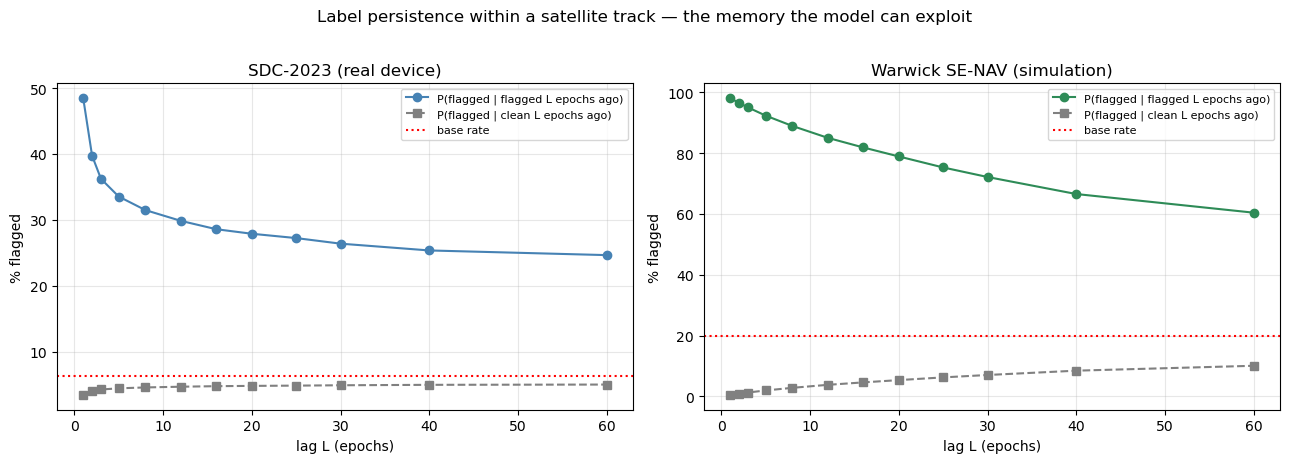

SDC-2023:
 lag  base  p_given_1  p_given_0
   1 0.063      0.485      0.035
   2 0.063      0.397      0.040
   3 0.063      0.362      0.043
   5 0.063      0.335      0.045
   8 0.063      0.315      0.046
  12 0.063      0.299      0.047
  16 0.063      0.286      0.048
  20 0.063      0.279      0.048
  25 0.063      0.272      0.049
  30 0.063      0.264      0.049
  40 0.063      0.254      0.050
  60 0.063      0.247      0.050

Warwick:
 lag  base  p_given_1  p_given_0
   1 0.200      0.981      0.005
   2 0.200      0.965      0.009
   3 0.200      0.950      0.013
   5 0.200      0.923      0.020
   8 0.200      0.889      0.028
  12 0.200      0.850      0.038
  16 0.200      0.819      0.046
  20 0.200      0.789      0.054
  25 0.200      0.753      0.062
  30 0.200      0.721      0.070
  40 0.199      0.665      0.085
  60 0.198      0.604      0.101


In [12]:
def persistence(df, group_cols, label_col, lags):
    d = df.sort_values(group_cols + (['t_s'] if 't_s' in df else ['epoch']), kind='stable')
    y = d[label_col].to_numpy()
    out = []
    for L in lags:
        s = d.groupby(group_cols, sort=False)[label_col].shift(L)
        m = s.notna().to_numpy()
        prev1 = m & (s.to_numpy() == 1)
        prev0 = m & (s.to_numpy() == 0)
        out.append(dict(lag=L, base=y[m].mean(),
                        p_given_1=y[prev1].mean() if prev1.any() else np.nan,
                        p_given_0=y[prev0].mean() if prev0.any() else np.nan))
    return pd.DataFrame(out)

LAGS = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30, 40, 60]
p_sdc = persistence(sdc, ['track'], 'MultipathIndicator', LAGS)
p_war = persistence(war, ['PRN'], 'multipath', LAGS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, p, name, colour in [(axes[0], p_sdc, 'SDC-2023 (real device)', 'steelblue'),
                            (axes[1], p_war, 'Warwick SE-NAV (simulation)', 'seagreen')]:
    ax.plot(p.lag, 100 * p.p_given_1, 'o-', color=colour, label='P(flagged | flagged L epochs ago)')
    ax.plot(p.lag, 100 * p.p_given_0, 's--', color='gray', label='P(flagged | clean L epochs ago)')
    ax.axhline(100 * p.base.iloc[0], color='red', ls=':', label='base rate')
    ax.set_xlabel('lag L (epochs)'); ax.set_ylabel('% flagged'); ax.set_title(name)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Label persistence within a satellite track — the memory the model can exploit', y=1.02)
plt.tight_layout(); plt.show()

print('SDC-2023:'); print(p_sdc.round(3).to_string(index=False))
print('\nWarwick:'); print(p_war.round(3).to_string(index=False))

Both datasets carry real memory, but of very different strength — SDC's advantage
over the base rate decays steadily across the 40-epoch window, whereas the
noise-free simulation stays extremely persistent. Note this asymmetry now: it means
the *absolute* attention weights of the two datasets are not directly comparable in
notebook 03, and only the **shape** of the discovered window is.

## 7. Export

Each cache stores per-row arrays plus the segment index. Notebook 02 reconstructs
windows for any `k <= K_MAX` with `valid_centers(seg, k)`.

Session and device are stored as small integer codes with a separate lookup table
rather than as per-row strings: numpy pads fixed-width unicode to 4 bytes per
character, so a per-row `U40` session column alone would cost ~115 MB — over half
the file, to store 17 distinct strings.

In [13]:
SPLIT_CODE = {'train': 0, 'val': 1, 'test': 2}

session_names, session_code = np.unique(sdc['session'].to_numpy(), return_inverse=True)
device_names, device_code = np.unique(sdc['device'].to_numpy(), return_inverse=True)

sdc_out = os.path.join(OUT_DIR, 'seq_sdc2023.npz')
np.savez(
    sdc_out,
    F_rich=F_rich_df.to_numpy(np.float32),
    F_shared=F_rich_df[SHARED_COLS].to_numpy(np.float32),
    y=sdc['MultipathIndicator'].to_numpy(np.int8),
    seg=sdc['seg'].to_numpy(np.int32),
    split=sdc['split'].map(SPLIT_CODE).to_numpy(np.int8),
    track=sdc['track'].to_numpy(np.int32),
    t_s=sdc['t_s'].to_numpy(np.float64),
    session_code=session_code.astype(np.int16),
    session_names=session_names.astype('U40'),
    device_code=device_code.astype(np.int8),
    device_names=device_names.astype('U20'),
    const=sdc['ConstellationType'].to_numpy(np.int16),
    svid=sdc['Svid'].to_numpy(np.int16),
    rich_features=np.array(RICH_FEATURES, dtype='U32'),
    shared_features=np.array(SHARED_FEATURES, dtype='U32'),
    k_max=np.int32(K_MAX),
)

war_out = os.path.join(OUT_DIR, 'seq_warwick.npz')
np.savez(
    war_out,
    F_own=W_df[WARWICK_OWN].to_numpy(np.float32),
    F_shared=W_df[SHARED_FEATURES].to_numpy(np.float32),
    y=war['multipath'].to_numpy(np.int8),
    seg=war['seg'].to_numpy(np.int32),
    split=war['split'].map(SPLIT_CODE).to_numpy(np.int8),
    track=war['PRN'].to_numpy(np.int32),
    epoch=war['epoch'].to_numpy(np.int32),
    own_features=np.array(WARWICK_OWN, dtype='U32'),
    shared_features=np.array(WARWICK_SHARED, dtype='U32'),
    k_max=np.int32(K_MAX),
)

for p in (sdc_out, war_out):
    print(f'{p}   {os.path.getsize(p)/1e6:.1f} MB')

C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed\seq_sdc2023.npz   78.7 MB
C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/03_processed\seq_warwick.npz   1.2 MB


### 7a. Read-back check

Re-open both caches, rebuild the `k = 20` windows and verify that every window is
contiguous in time, sits inside one satellite track, and never crosses a split
boundary. These are the invariants the whole study rests on, so they are asserted
rather than eyeballed.

In [14]:
z = np.load(sdc_out, allow_pickle=False)
seg, tr, ts, sp = z['seg'], z['track'], z['t_s'], z['split']
c = valid_centers(seg, K_MAX)
off = np.arange(-K_MAX, K_MAX + 1)
sample = c[np.random.default_rng(0).choice(len(c), size=min(20000, len(c)), replace=False)]
idx = sample[:, None] + off[None, :]

assert (tr[idx] == tr[idx][:, :1]).all(),           'a window spans two satellite tracks'
assert (sp[idx] == sp[idx][:, :1]).all(),           'a window crosses a split boundary'
assert (seg[idx] == seg[idx][:, :1]).all(),         'a window spans two segments'
assert (np.diff(ts[idx], axis=1) <= MAX_GAP_S).all(), 'a window bridges a sampling gap'
assert (np.diff(ts[idx], axis=1) > 0).all(),        'a window is not strictly time-ordered'

zw = np.load(war_out, allow_pickle=False)
cw = valid_centers(zw['seg'], K_MAX)
idxw = cw[:, None] + off[None, :]
assert (zw['track'][idxw] == zw['track'][idxw][:, :1]).all(), 'Warwick window spans two PRNs'
assert (zw['split'][idxw] == zw['split'][idxw][:, :1]).all(), 'Warwick window crosses a split'

print(f'SDC-2023 : {len(c):,} windows at k={K_MAX}  '
      f'(train/val/test = {(sp[c]==0).sum():,}/{(sp[c]==1).sum():,}/{(sp[c]==2).sum():,})')
print(f'Warwick  : {len(cw):,} windows at k={K_MAX}  '
      f'(train/val/test = {(zw["split"][cw]==0).sum():,}/{(zw["split"][cw]==1).sum():,}/'
      f'{(zw["split"][cw]==2).sum():,})')
print('\nAll windowing invariants hold — contiguous, single-track, split-respecting.')

SDC-2023 : 500,834 windows at k=20  (train/val/test = 273,615/71,914/155,305)
Warwick  : 20,023 windows at k=20  (train/val/test = 14,018/1,238/4,767)

All windowing invariants hold — contiguous, single-track, split-respecting.


## 8. Summary

- SDC-2023 measurements are grouped into satellite tracks keyed on
  `(session, device, ConstellationType, Svid, CarrierFrequencyHz)` — the naive
  `(session, device, Svid)` key is corrupted by dual-band L1/L5 tracking and by
  `Svid` reuse across constellations.
- Windows of `2k+1` epochs are defined only inside contiguous 1 Hz segments of a
  single track, never bridging a data gap or a split boundary; edge windows are
  dropped, not padded.
- The split holds out **entire drives**, so nothing about a test route is visible
  during training.
- Both datasets show genuine label persistence along a track, so there is memory
  for the attention block to find — much stronger in the noise-free simulation
  than on the real device.

Next: `02_sdc_attention_brnn.ipynb` trains the BiLSTM/BiGRU + attention models on
these windows and reads the useful window width off the attention weights.